Hierarchical Clustering

In [1]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
#Load the dataset
df = pd.read_csv("Mall_Customers.csv")
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
#Select features
X = df[["Annual Income (k$)", "Spending Score (1-100)"]]

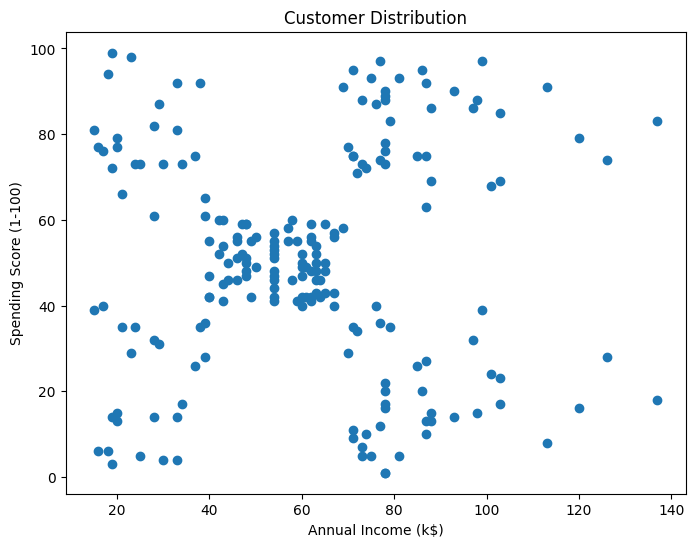

In [4]:
#Visualize them:
plt.figure(figsize=(8, 6))
plt.scatter(
    X["Annual Income (k$)"],
    X["Spending Score (1-100)"]
)
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Customer Distribution")
plt.show()

In [5]:
#Scaling the Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

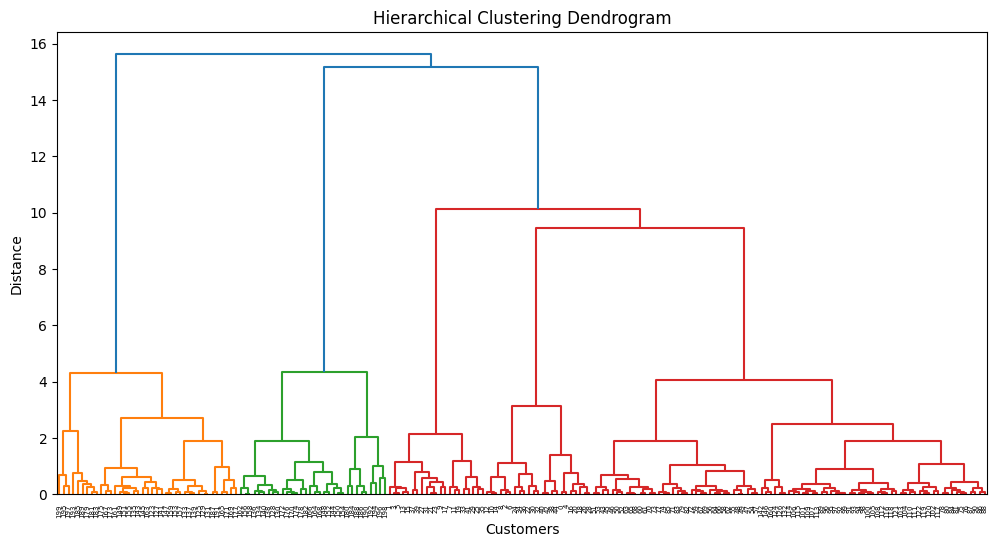

In [6]:
#Creating the Dendrogram
linked = linkage(X_scaled, method="ward")
plt.figure(figsize=(12, 6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance")
plt.show()

In [7]:
#Applying Agglomerative Clustering
hc = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)
y_hc = hc.fit_predict(X_scaled)

In [9]:
#Now add the cluster labels to our dataset:
df["Cluster"] = y_hc
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,4
1,2,Male,21,15,81,3
2,3,Female,20,16,6,4
3,4,Female,23,16,77,3
4,5,Female,31,17,40,4


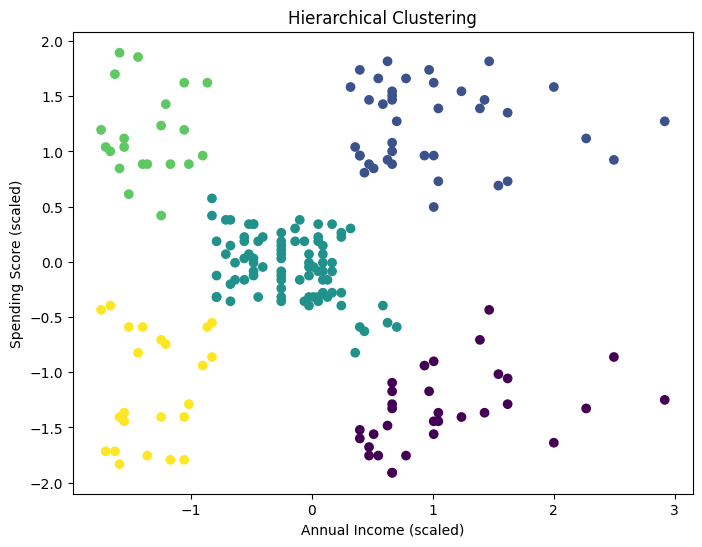

In [10]:
#Visualizing the Clusters
plt.figure(figsize=(8, 6))
plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=y_hc
)
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.title("Hierarchical Clustering")
plt.show()

In [11]:
#Understanding the Clusters
df.groupby("Cluster")[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]].mean()

,Annual Income (k$),Spending Score (1-100)
Cluster,,
0,89.406250,15.593750
1,86.538462,82.128205
2,55.811765,49.129412
3,25.095238,80.047619
4,26.304348,20.913043
